In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import seaborn as sns 
from collections import Counter

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adadelta, Nadam

import keras_tuner as kt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, NearMiss


2024-03-28 10:14:01.023073: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-28 10:14:01.026127: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-28 10:14:01.046825: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-28 10:14:03.149676: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.experimental.set_visible_devices([], 'GPU')

2024-03-28 10:14:59.156021: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 10:14:59.762951: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 10:14:59.763006: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


# Utils definitions

In [3]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

def scale_objects(df, scaler):
    array_scaled = scaler.transform(df)
    df_scaled = pd.DataFrame(array_scaled, columns=df.columns)
    return df_scaled

def df_boxplots(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.boxplot(df[col], vert=0)
            plt.ylabel(col)
            plt.show()

def df_hist(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.hist(df[col])
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()

# Reading and checking dataset out

In [4]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

In [5]:
df_init['label'].value_counts()

label
smurf.              2807886
neptune.            1072017
normal.              972781
satan.                15892
ipsweep.              12481
portsweep.            10413
nmap.                  2316
back.                  2203
warezclient.           1020
teardrop.               979
pod.                    264
guess_passwd.            53
buffer_overflow.         30
land.                    21
warezmaster.             20
imap.                    12
rootkit.                 10
loadmodule.               9
ftp_write.                8
multihop.                 7
phf.                      4
perl.                     3
spy.                      2
Name: count, dtype: int64

In [6]:
df_init['service'].value_counts()

service
ecr_i        2811660
private      1100831
http          623091
smtp           96554
other          72653
              ...   
tftp_u             3
harvest            2
aol                2
http_8001          2
http_2784          1
Name: count, Length: 70, dtype: int64

# Preprocessing

## Feature selection

In [7]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [8]:
df_feature_selected.head()

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
0,tcp,SF,45076,1,1,1,0.0,0.0,1.0,0.0,0,0,0.0,0.00,0.0,normal.
1,tcp,SF,4528,1,2,2,0.0,0.0,1.0,0.0,1,1,1.0,1.00,0.0,normal.
2,tcp,SF,1228,1,1,1,0.0,0.0,1.0,0.0,2,2,1.0,0.50,0.0,normal.
3,tcp,SF,2032,1,2,2,0.0,0.0,1.0,0.0,3,3,1.0,0.33,0.0,normal.
4,tcp,SF,486,1,3,3,0.0,0.0,1.0,0.0,4,4,1.0,0.25,0.0,normal.


In [9]:
df_feature_selected.shape

(4898431, 16)

In [10]:
# Encoding data

df_feature_selected_encoded = encode_objects(df_feature_selected)

/tmp/ipykernel_515/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
/tmp/ipykernel_515/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])


In [11]:
df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

/tmp/ipykernel_515/1445368458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)


In [12]:
df_feature_selected_encoded['label'].value_counts()

label
1    3925650
0     972781
Name: count, dtype: int64

## Visualizing distributions

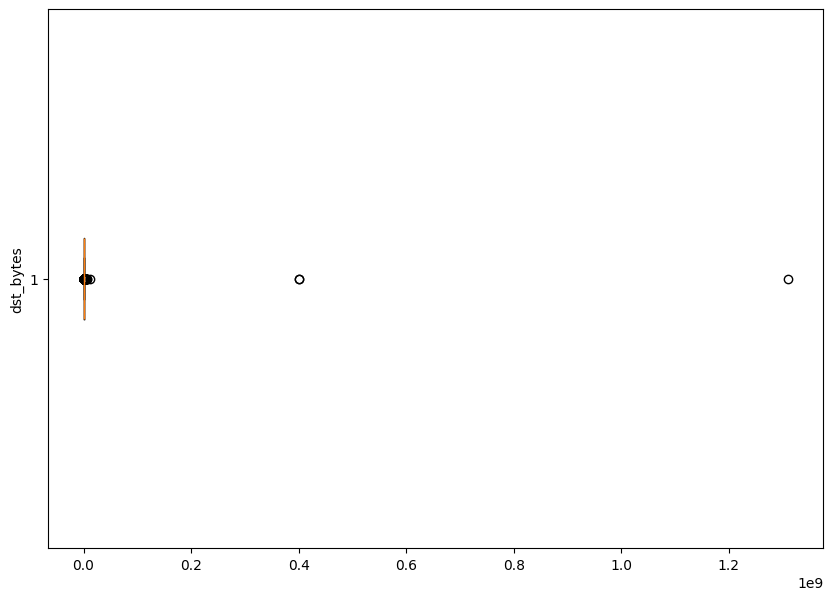

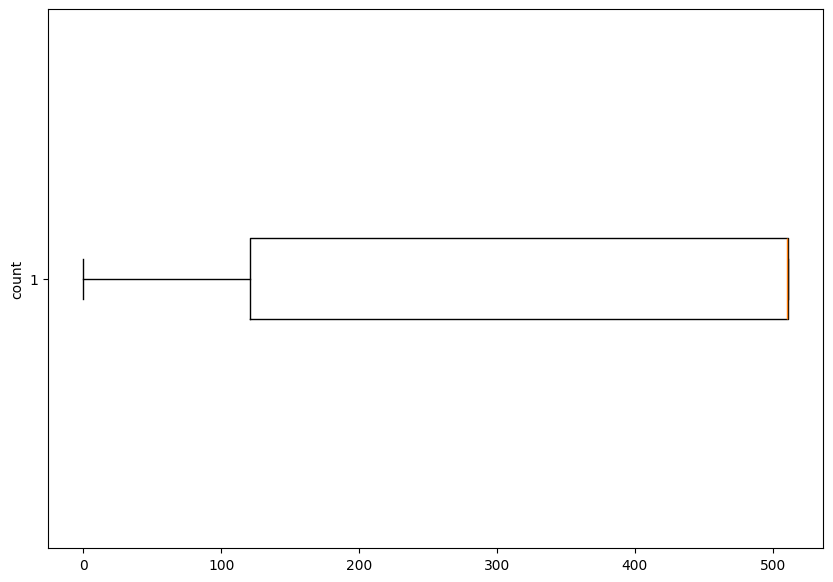

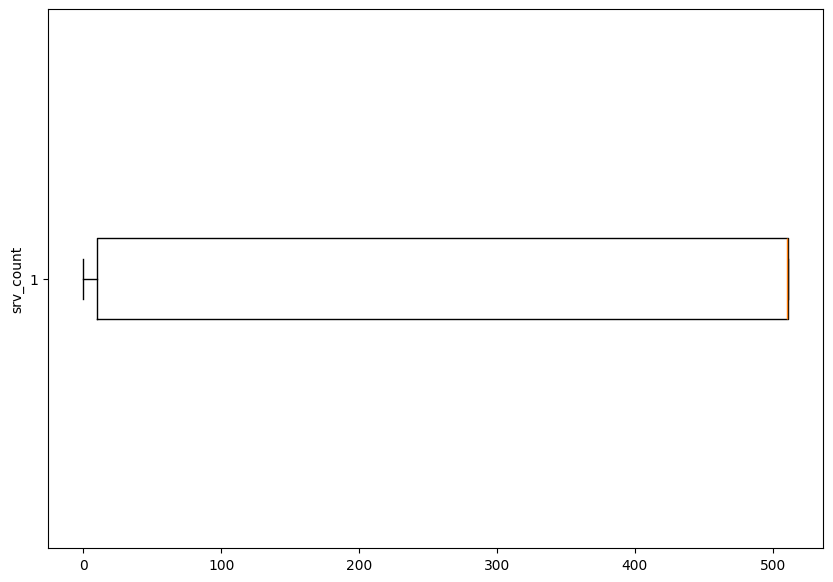

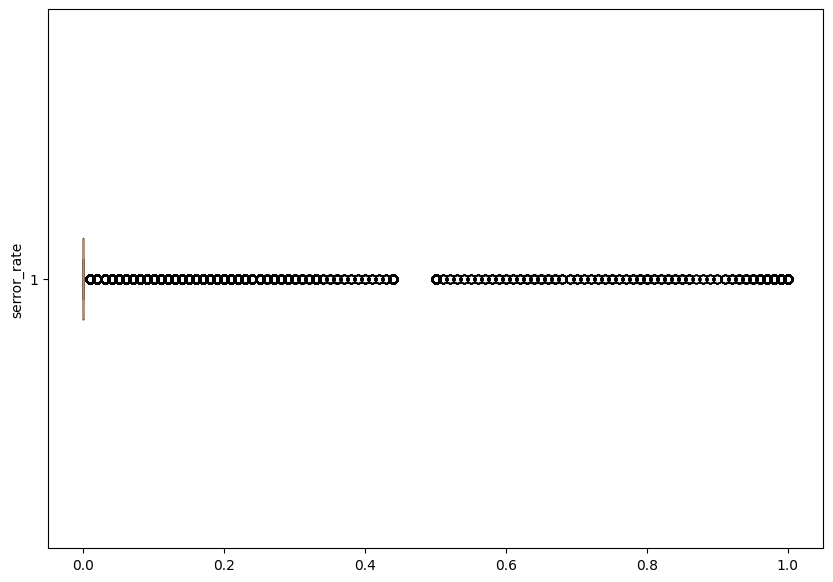

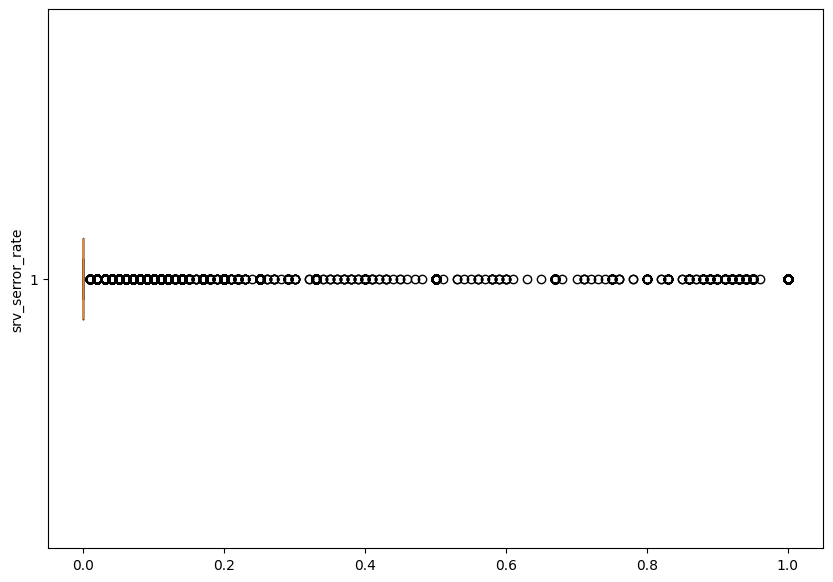

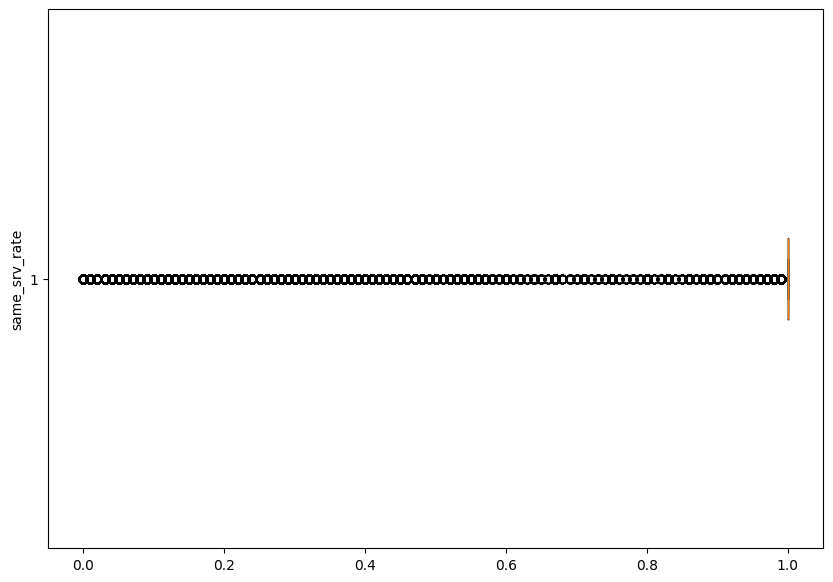

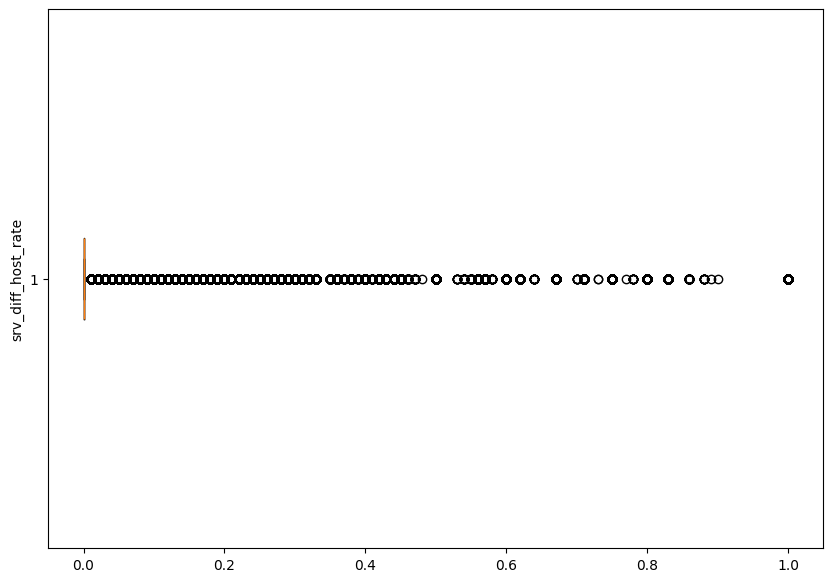

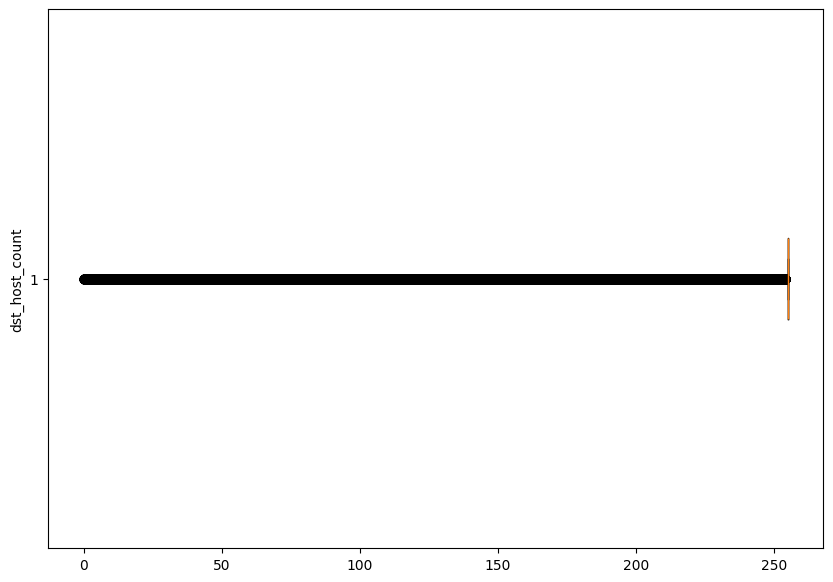

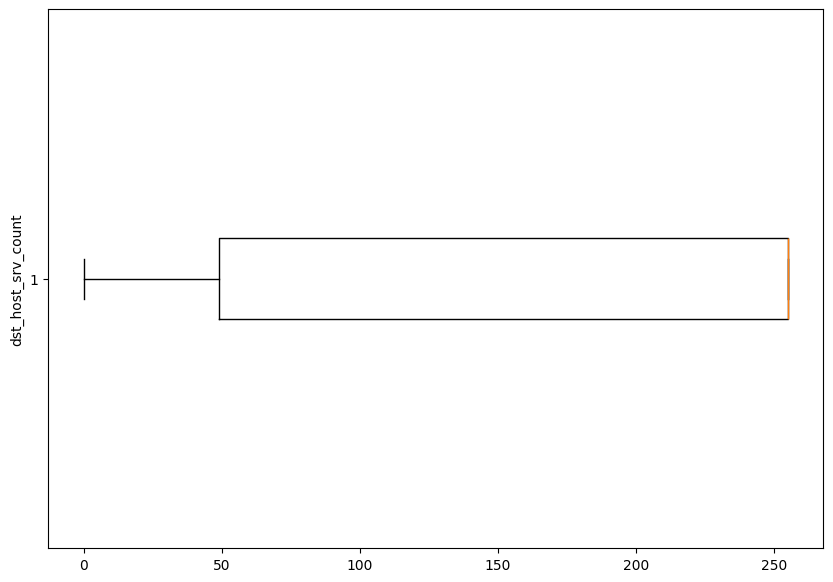

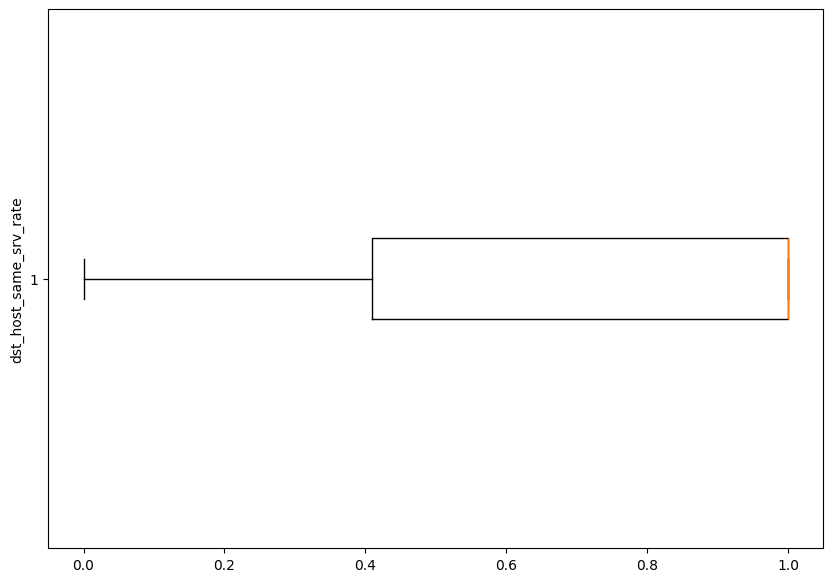

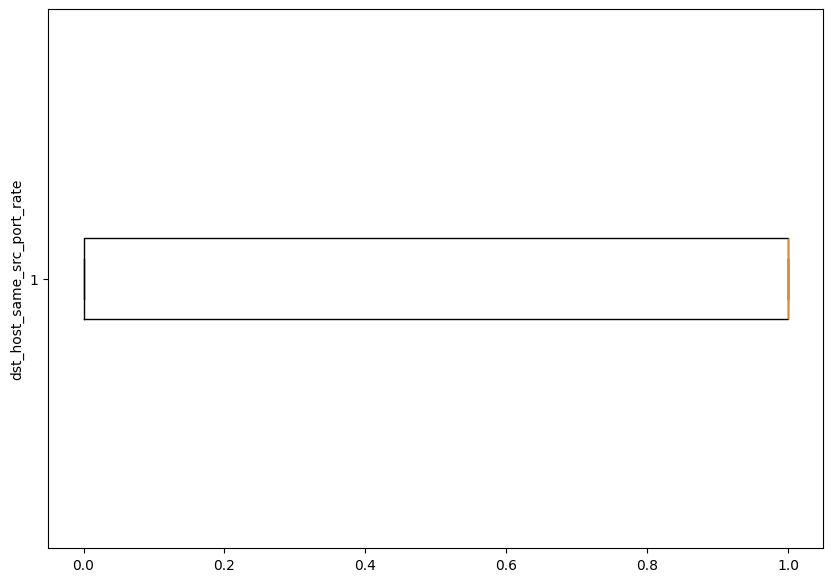

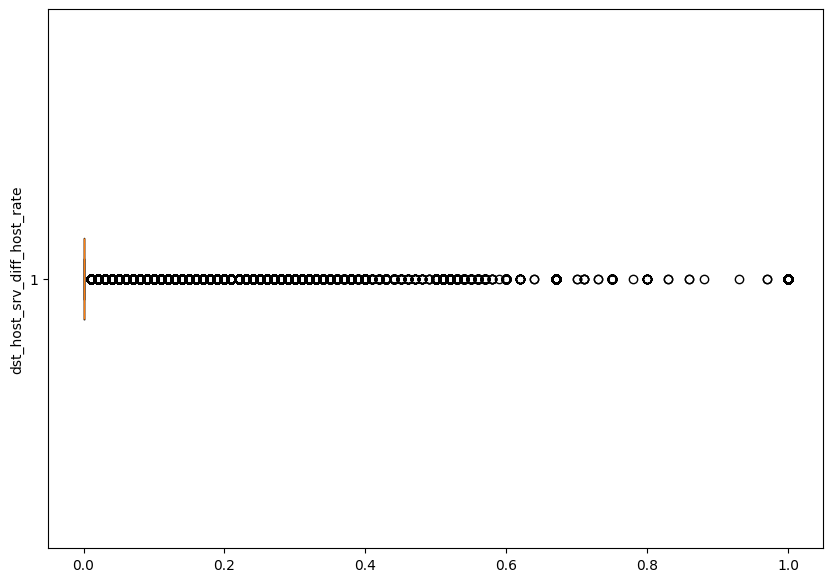

In [13]:
df_boxplots(df_feature_selected_encoded)

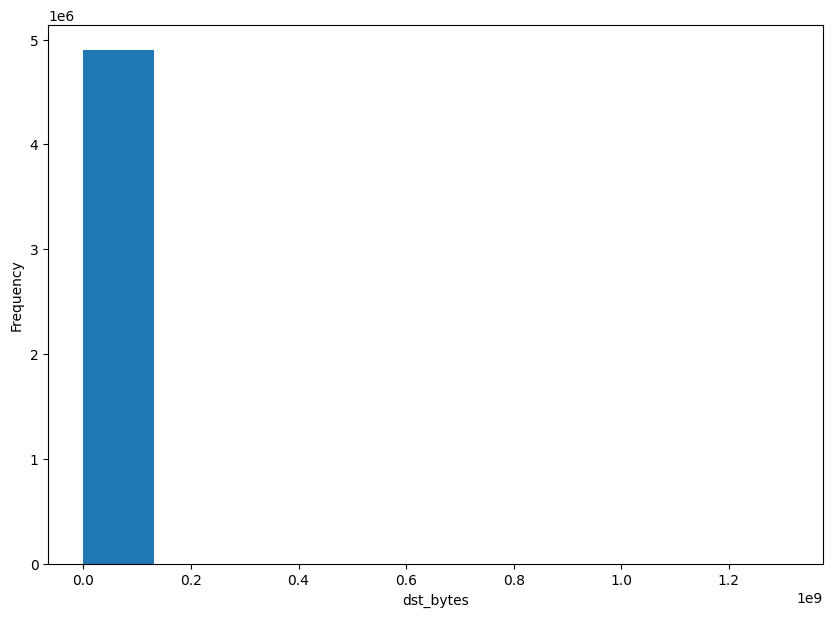

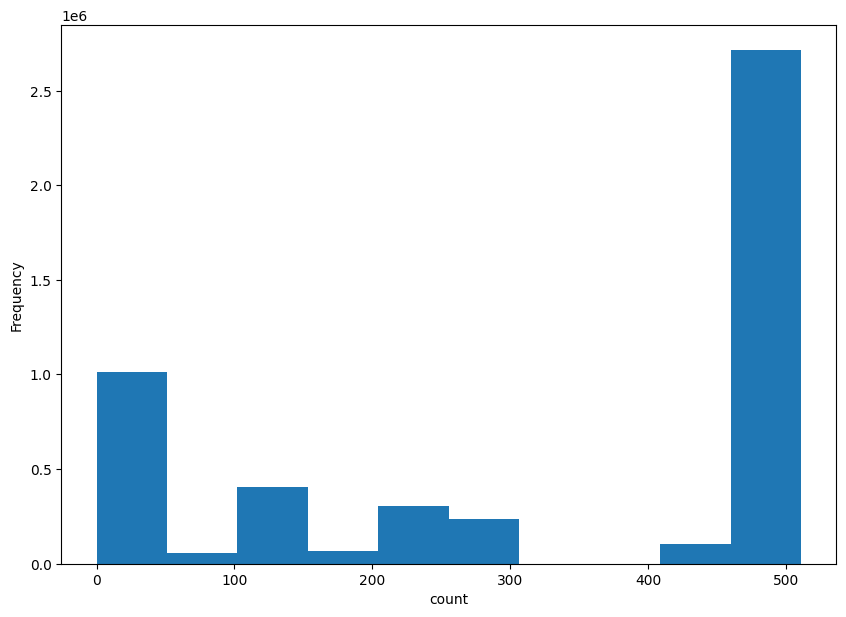

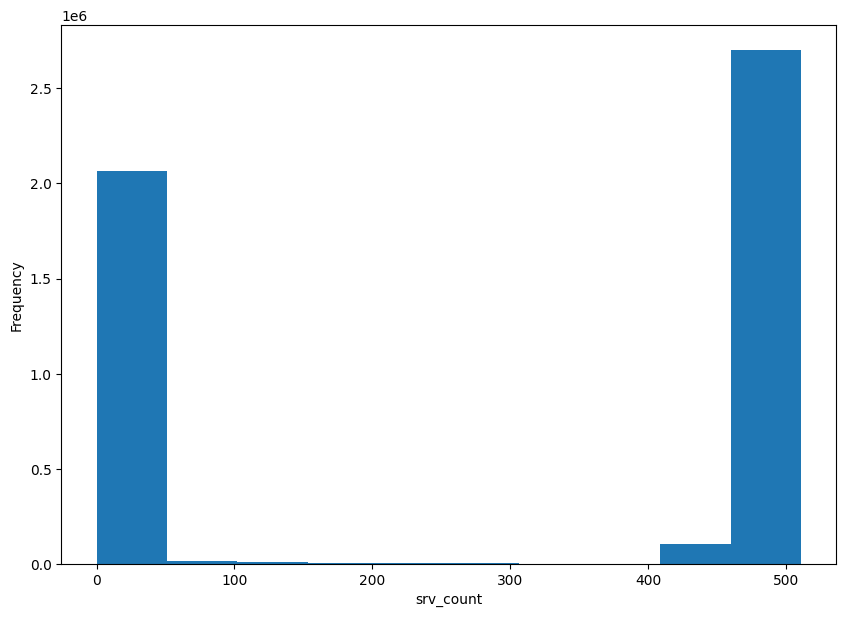

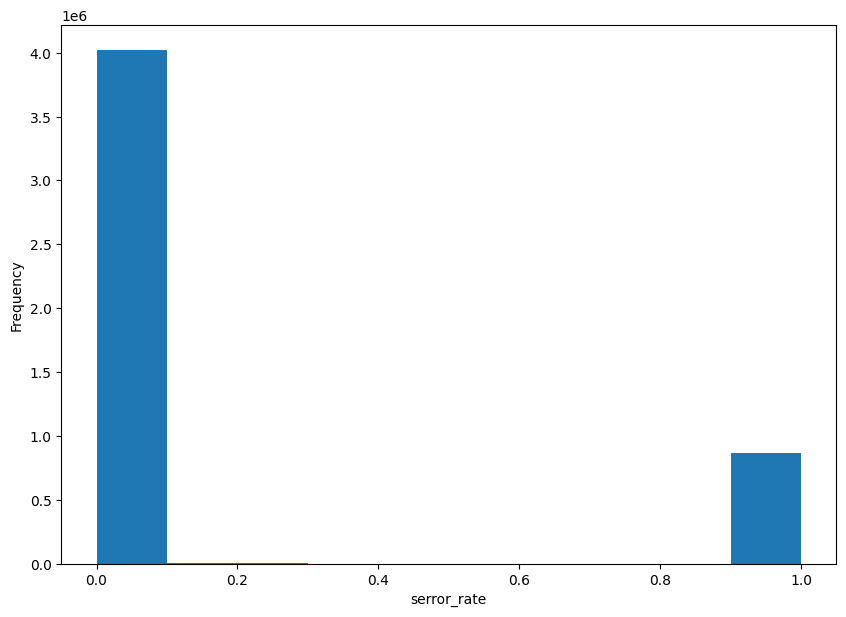

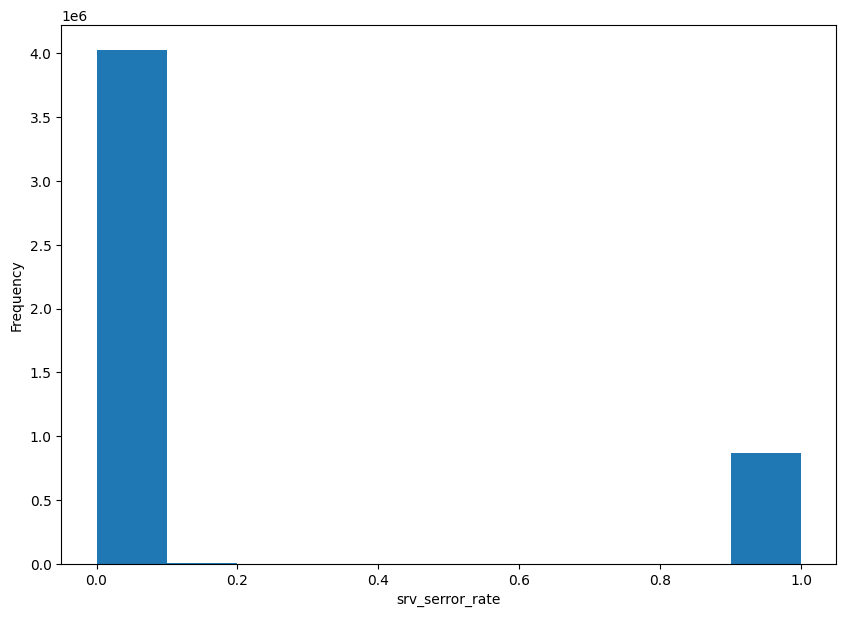

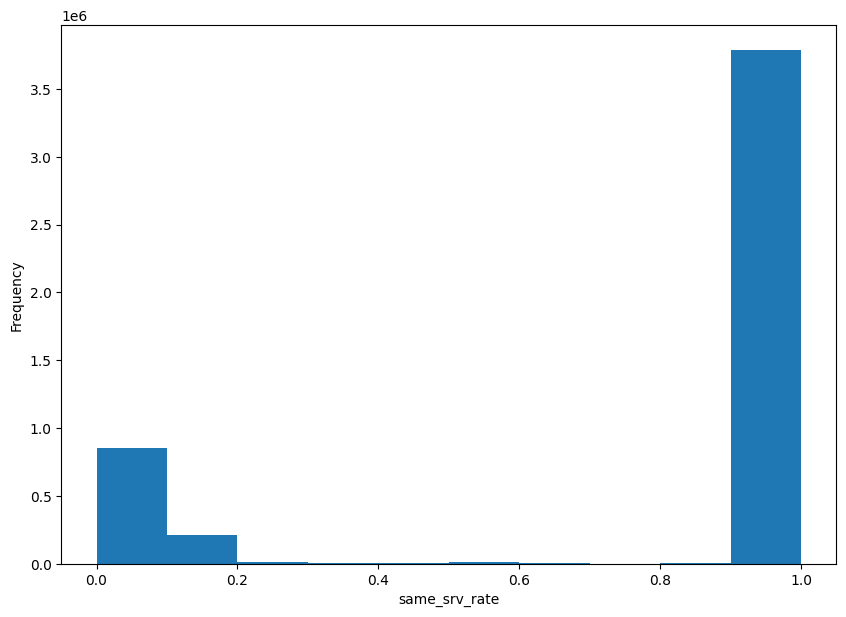

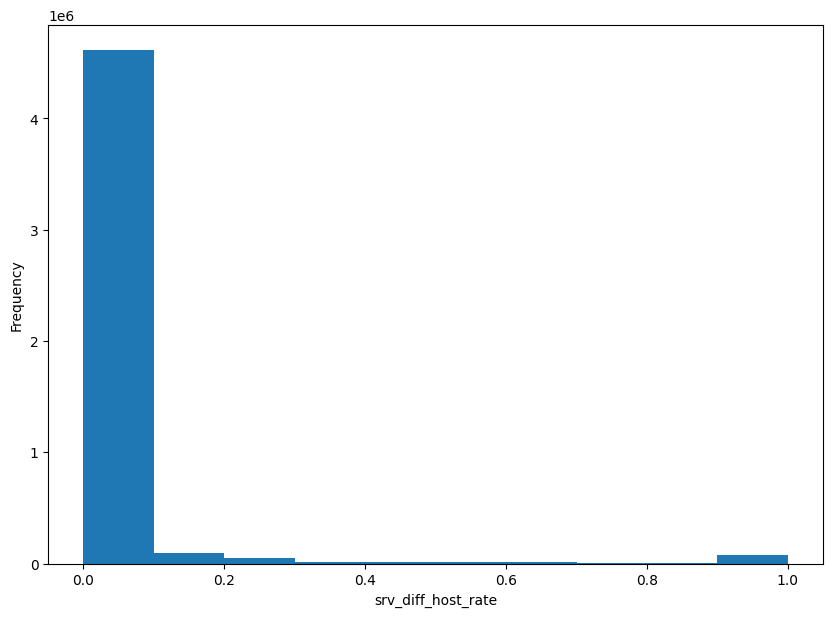

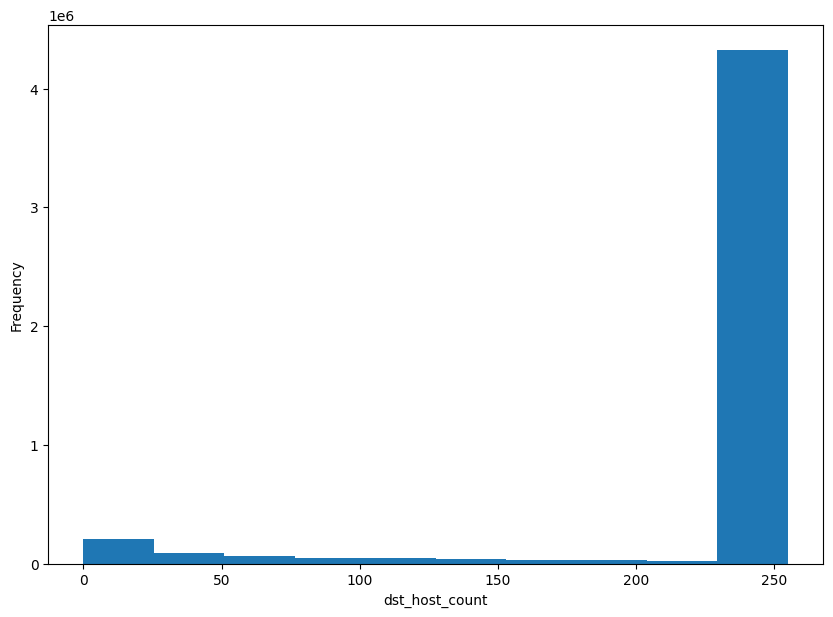

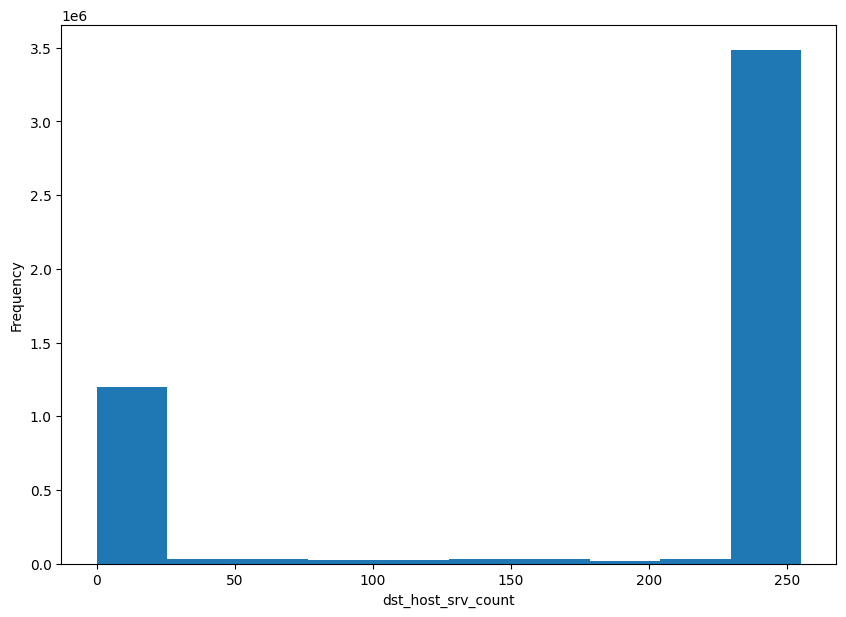

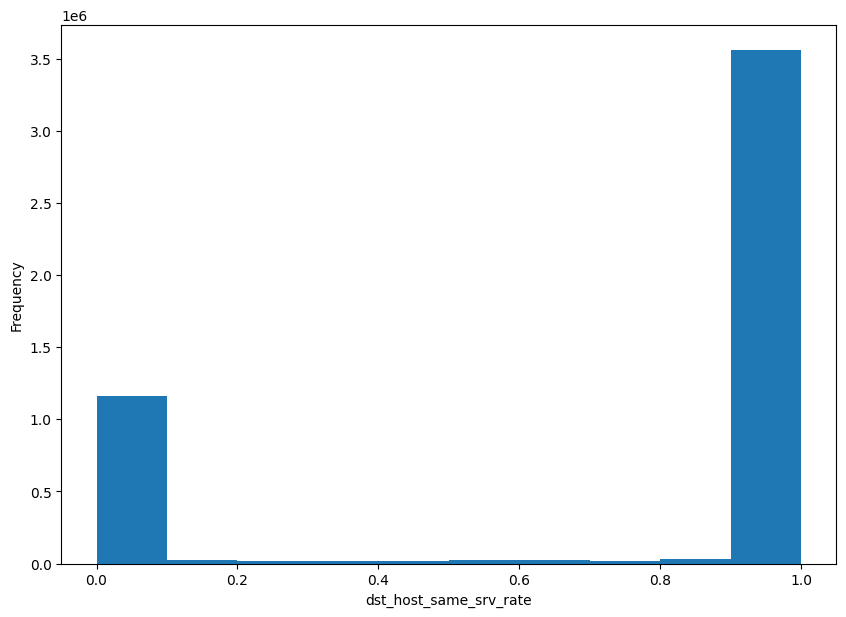

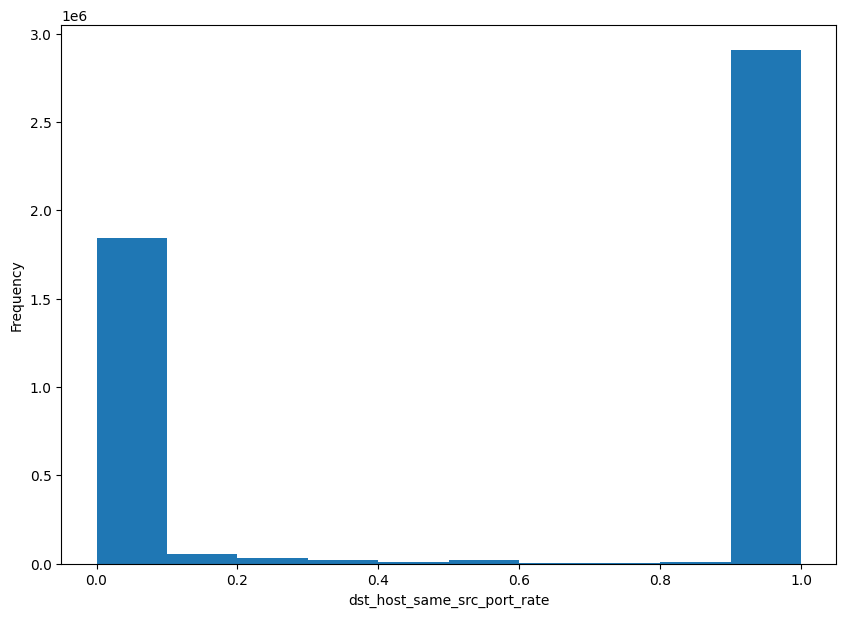

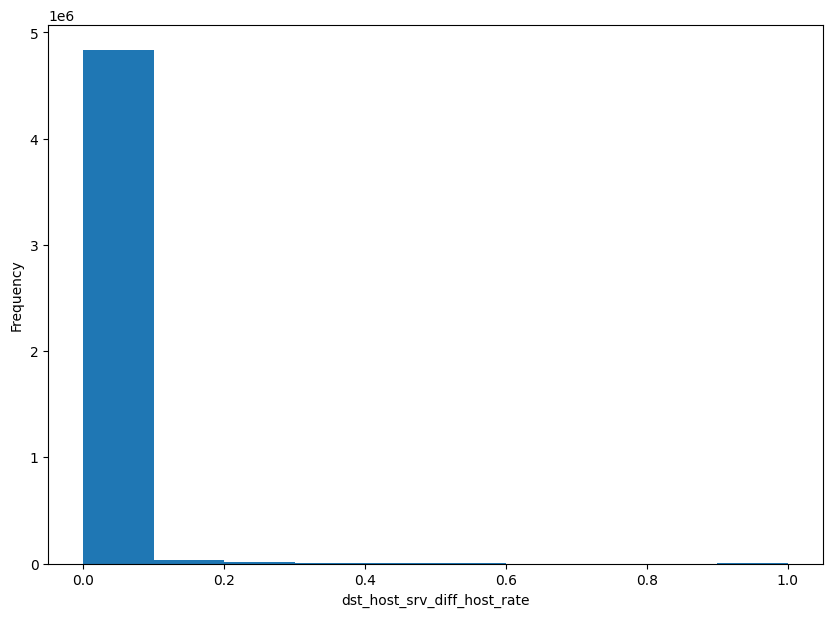

In [14]:
df_hist(df_feature_selected_encoded)

## Removing outliers

In [15]:
df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 1e8]

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
1415575,1,4,400291060,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1
1415576,1,4,400291060,0,2,2,0.0,0.0,1.0,0.0,255,2,0.01,1.0,0.0,1
1417571,1,4,1309937401,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1


In [16]:
df_feature_selected_encoded.shape

(4898431, 16)

In [17]:
df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)
df_feature_selected_encoded.shape

(4898428, 16)

In [18]:
normal = df_feature_selected_encoded.query('label == 0').sample(100000)
attack = df_feature_selected_encoded.query('label == 1').sample(100000)

df_reduced = pd.concat([normal, attack])
df_reduced

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
3679924,1,1,0,0,1,1,0.0,0.0,1.0,0.0,48,255,1.00,0.02,0.15,0
224298,1,9,22691,1,2,2,0.0,0.0,1.0,0.0,255,255,1.00,0.00,0.00,0
4773718,0,9,0,0,5,4,0.0,0.0,0.8,0.0,255,50,0.20,0.22,0.00,0
20357,1,9,463,1,1,2,0.0,0.5,1.0,1.0,1,255,1.00,1.00,0.05,0
255720,1,9,327,1,1,1,0.0,0.0,1.0,0.0,118,54,0.46,0.01,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1969830,0,9,0,0,511,511,0.0,0.0,1.0,0.0,255,255,1.00,1.00,0.00,1
1564441,0,9,0,0,510,510,0.0,0.0,1.0,0.0,255,255,1.00,1.00,0.00,1
3199908,0,9,0,0,511,511,0.0,0.0,1.0,0.0,255,255,1.00,1.00,0.00,1
1709056,0,9,0,0,511,511,0.0,0.0,1.0,0.0,255,255,1.00,1.00,0.00,1


## Creating test, train, validation dataframes

In [19]:
labels = df_reduced['label']
features = df_reduced.drop("label", axis=1)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

In [22]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000,)

x_val:(48000, 15)
y_val:(48000,)

x_test:(40000, 15)
y_test:(40000,)


In [23]:
print(Counter(y_train))
print(Counter(y_val))

Counter({0: 56075, 1: 55925})
Counter({1: 24068, 0: 23932})


## Normalizing data

In [24]:
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scale_objects(x_train, scaler)
x_val = scale_objects(x_val, scaler)
x_test = scale_objects(x_test, scaler)

In [25]:
x_test

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
0,0.0,0.888889,0.000000,0.0,1.000000,1.000000,0.0,0.0,1.00,0.0,1.000000,1.000000,1.00,1.00,0.00
1,0.5,0.888889,0.000258,1.0,0.046967,0.046967,0.0,0.0,1.00,0.0,1.000000,1.000000,1.00,0.00,0.00
2,0.5,0.444444,0.000000,0.0,0.264188,0.013699,1.0,1.0,0.05,0.0,1.000000,0.054902,0.05,0.00,0.00
3,0.5,0.888889,0.003187,1.0,0.019569,0.019569,0.0,0.0,1.00,0.0,0.364706,1.000000,1.00,0.01,0.01
4,0.5,0.888889,0.000690,1.0,0.001957,0.003914,0.0,0.0,1.00,1.0,0.086275,1.000000,1.00,0.05,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.0,0.888889,0.000000,0.0,0.001957,0.001957,0.0,0.0,1.00,0.0,0.345098,0.345098,1.00,1.00,0.00
39996,1.0,0.888889,0.000029,0.0,0.003914,0.003914,0.0,0.0,1.00,0.0,1.000000,0.886275,0.89,0.01,0.00
39997,0.0,0.888889,0.000000,0.0,0.001957,0.001957,0.0,0.0,1.00,0.0,0.003922,0.396078,1.00,1.00,1.00
39998,0.5,0.000000,0.000000,0.0,0.199609,0.003914,0.0,0.0,0.02,0.0,1.000000,0.007843,0.01,0.00,0.00


### Visualise scaled data histograms

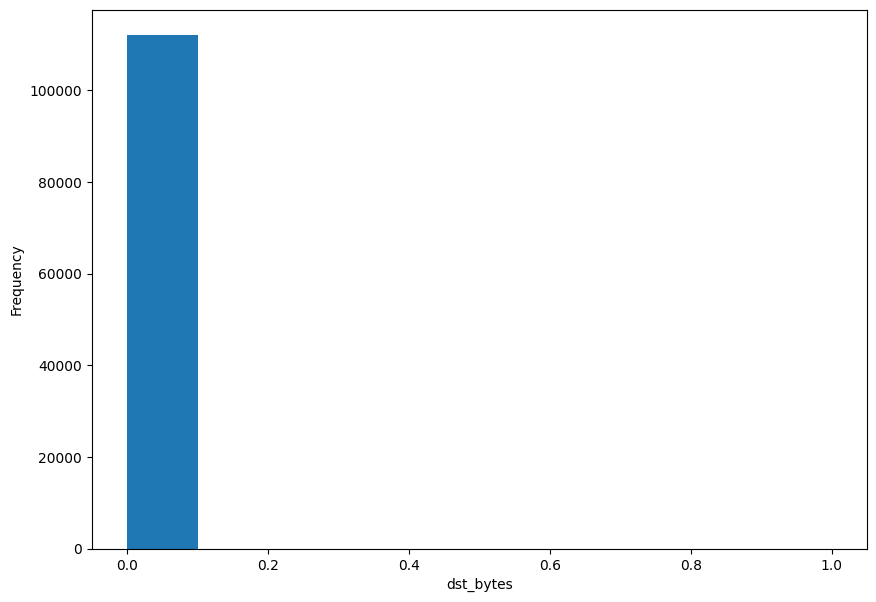

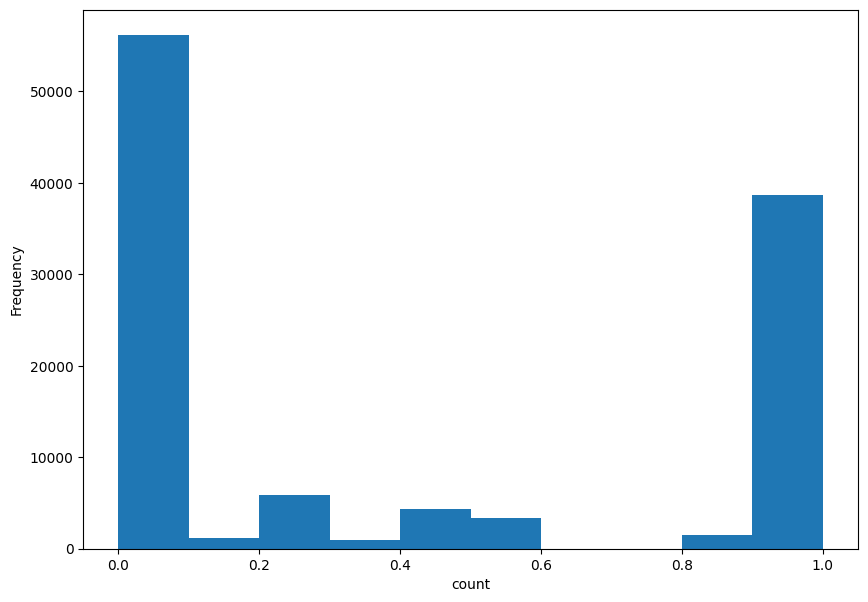

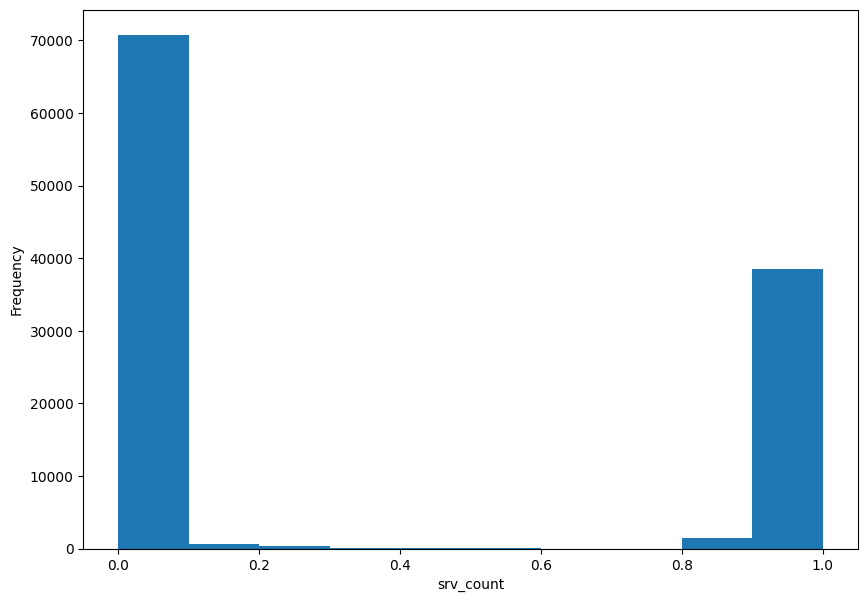

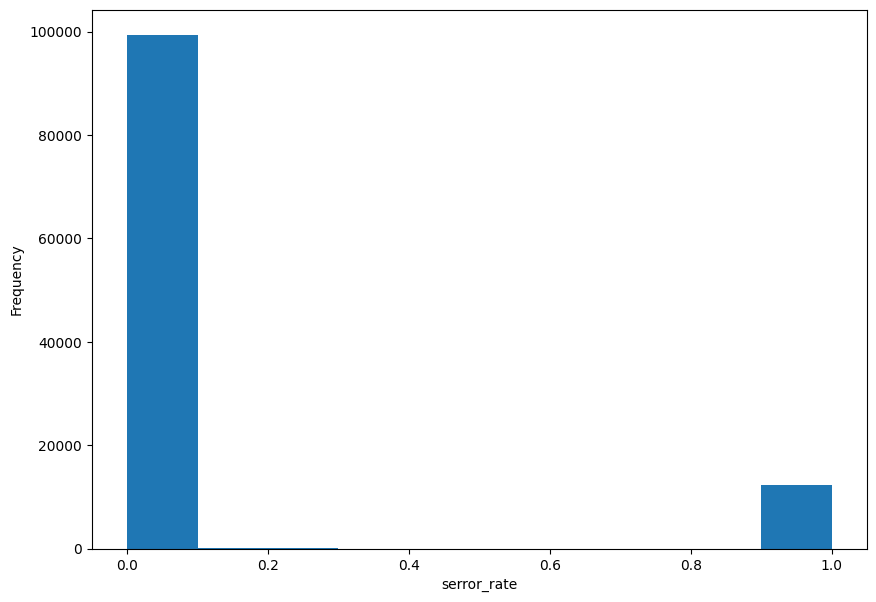

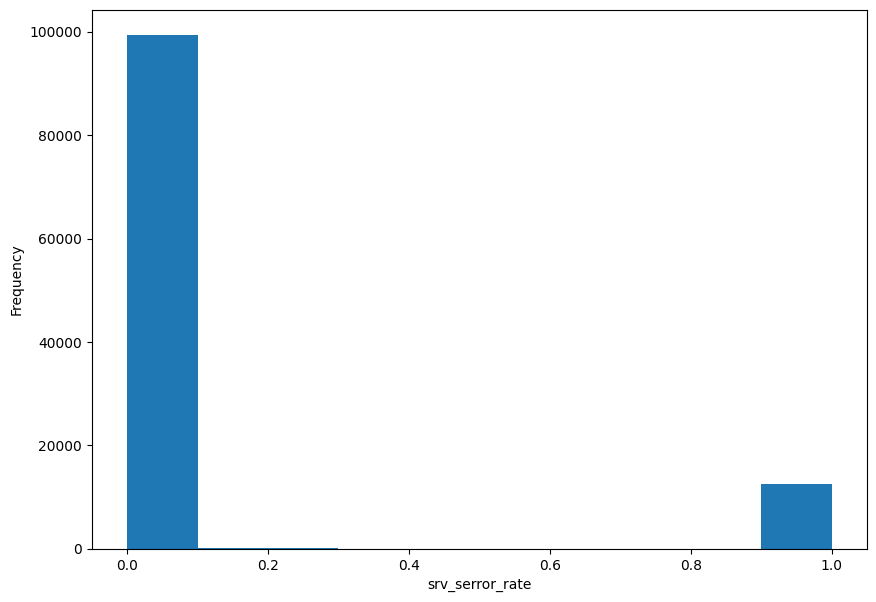

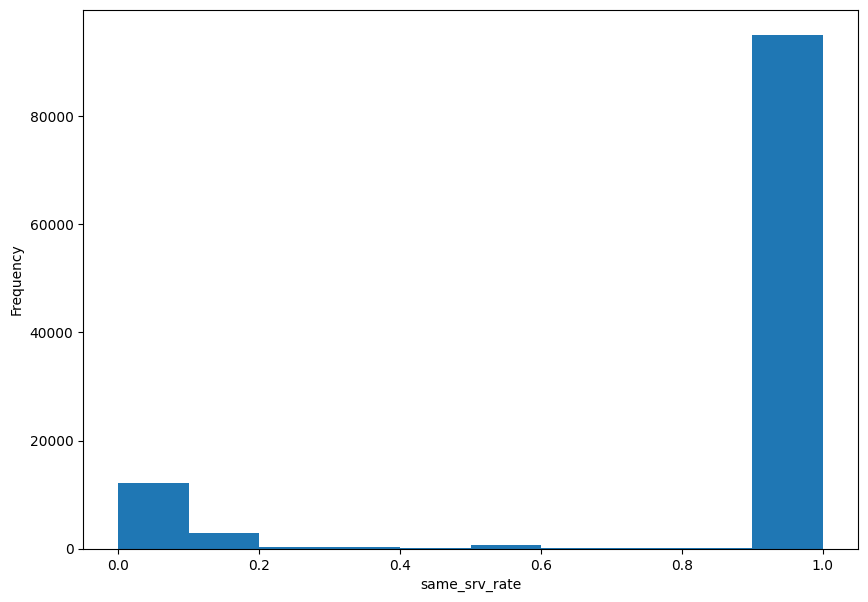

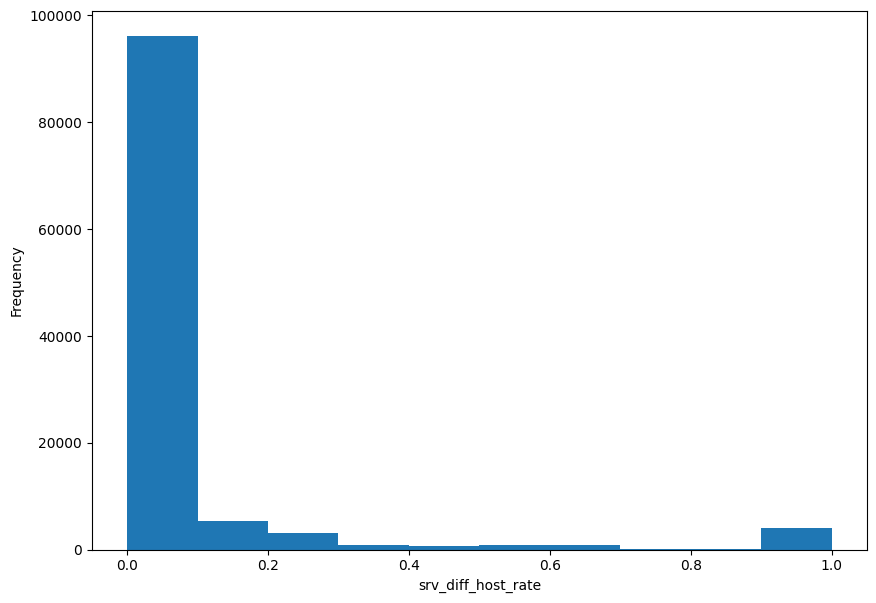

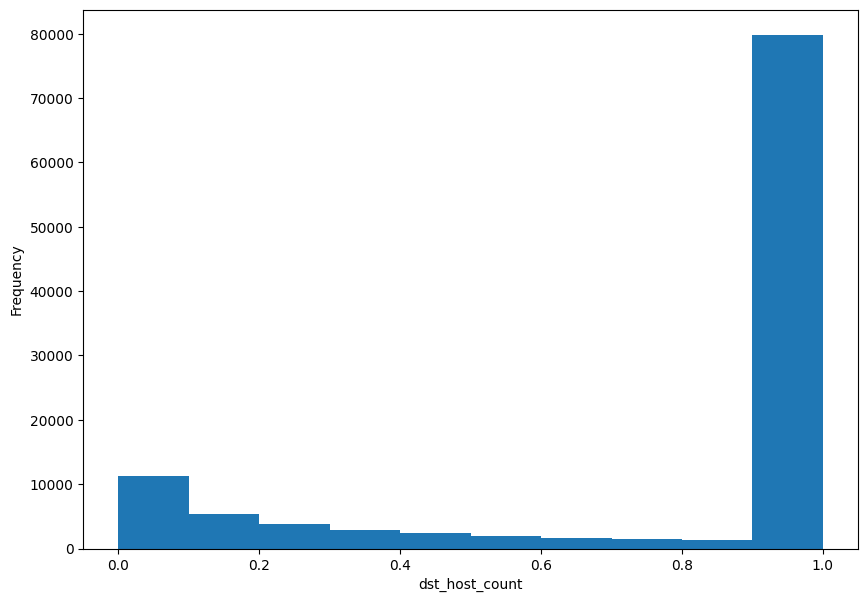

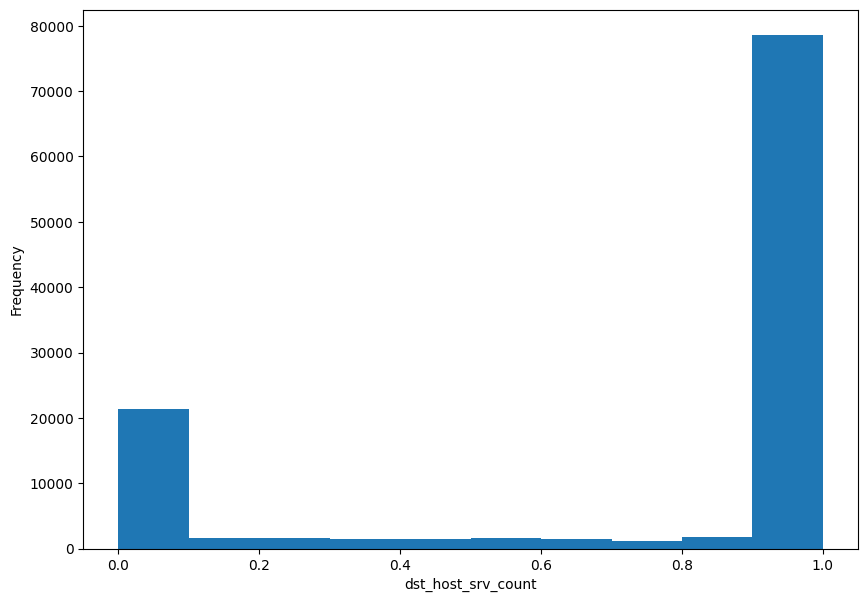

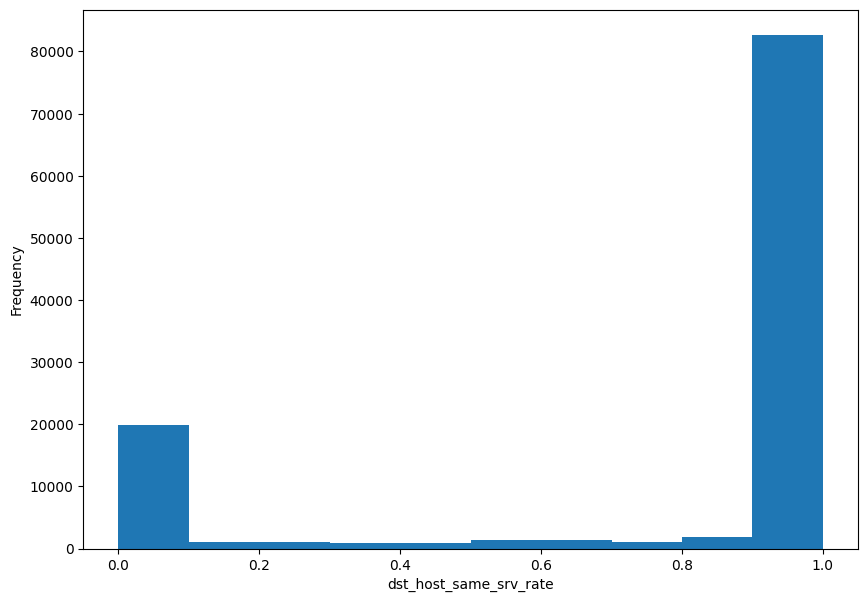

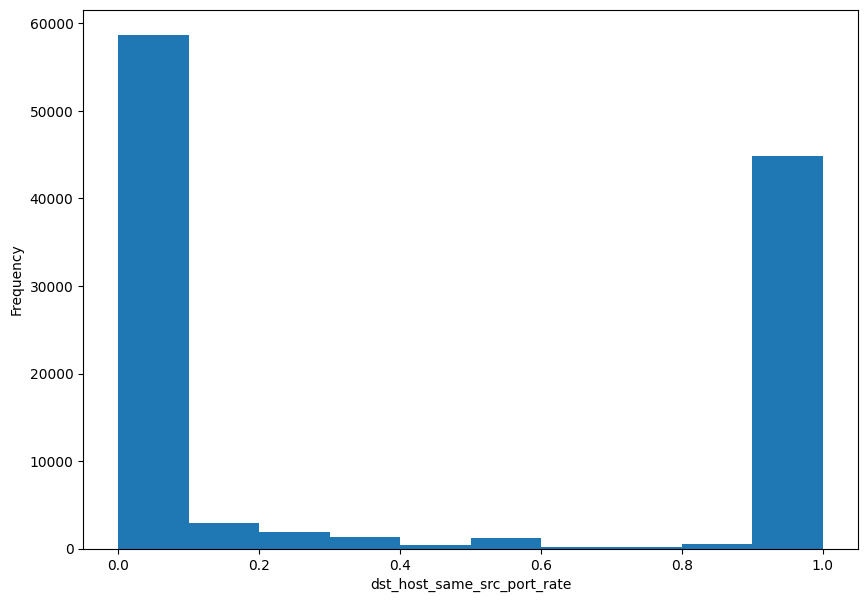

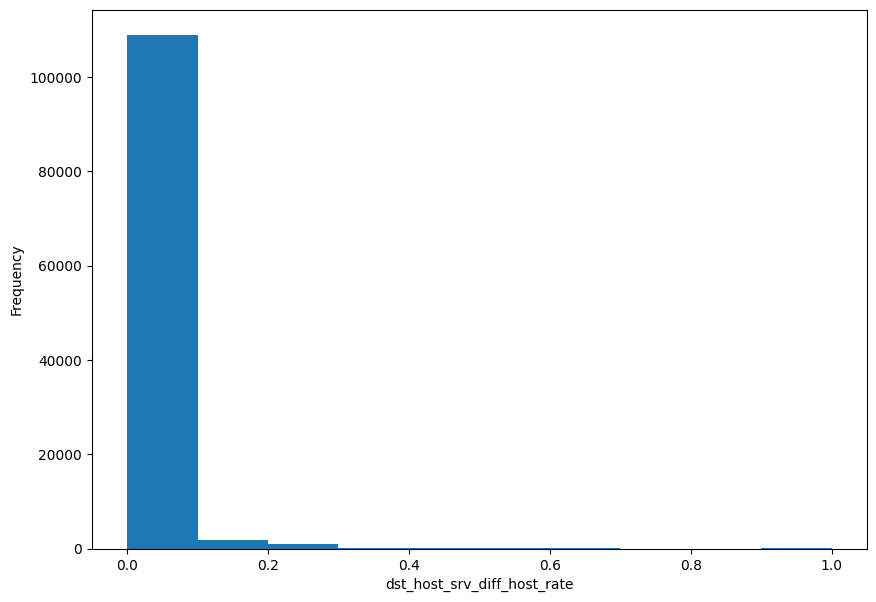

In [26]:
df_hist(x_train)

In [27]:
y_train =  to_categorical(y_train)
y_test =  to_categorical(y_test)
y_val =  to_categorical(y_val)

In [28]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000, 2)

x_val:(48000, 15)
y_val:(48000, 2)

x_test:(40000, 15)
y_test:(40000, 2)


# Model training

## Simple MLP

In [29]:
# The input layer requires you to specify the dimensionality of the x-features (and not the number of samples)
input_layer = Input(shape=(15,))
h1 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(input_layer)
h2 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(h1)
output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(h2)

# Creating a model by specifying the input layer and output layer
model = Model(input_layer, output_layer)

In [30]:
es = EarlyStopping(patience=5, min_delta=1e-3, monitor='val_loss', restore_best_weights=True, verbose=1)
rLROnP = ReduceLROnPlateau(patience=5, min_delta=1e-3, factor=0.05, mode="auto", verbose=1, cooldown=0, min_lr=0.0)

callbacks = [es, rLROnP]

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
epochs = 30
batch_size = 64

history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=callbacks)

Epoch 1/30


2024-03-28 10:15:39.626188: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fcbd000d7f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2024-03-28 10:15:39.626241: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2024-03-28 10:15:39.929996: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  66/1750 [>.............................] - ETA: 3s - loss: 0.2315 - accuracy: 0.9773 

2024-03-28 10:15:40.897094: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-03-28 10:15:40.902331: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:15:40.902564: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:15:40.902802: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:15:40.906483: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:15:40.912623: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:15:40.915127: E ./tensorflow/compiler/xla/stream_executor/stream_executor_int

1750/1750 [==============================] - 8s 3ms/step - loss: 0.0204 - accuracy: 0.9974 - val_loss: 0.0088 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 2/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0076 - accuracy: 0.9987 - val_loss: 0.0080 - val_accuracy: 0.9986 - lr: 0.0010
Epoch 3/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0070 - accuracy: 0.9988 - val_loss: 0.0077 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 4/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0065 - accuracy: 0.9989 - val_loss: 0.0075 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 5/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0061 - accuracy: 0.9990 - val_loss: 0.0073 - val_accuracy: 0.9988 - lr: 0.0010
Epoch 6/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0059 - accuracy: 0.9990 - val_loss: 0.0071 - val_accuracy: 0.9988 - lr: 0.0010
Epoch 7/30
1750/1750 [==============================] - 5s 3ms/step -

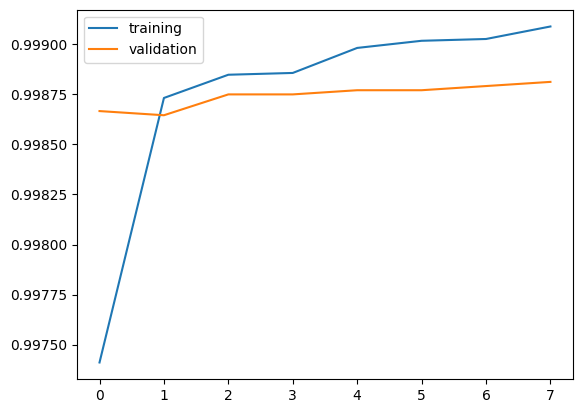

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

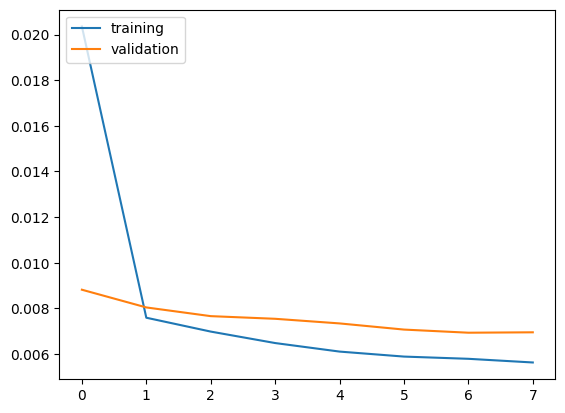

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

# Evaluating model

In [34]:
model.evaluate(x_test, y_test)

1250/1250 [==============================] - 2s 2ms/step - loss: 0.0081 - accuracy: 0.9987


[0.00806770846247673, 0.9987000226974487]

In [35]:
preds = model.predict(x_test)

# One hot to the original label encodings
y_true = y_test.argmax(axis=1)

# Derive the label predictions from the probability scores
y_preds = preds.argmax(axis=1)

# Compute precision, recall, f1 scores
precision = precision_score(y_true, y_preds)
recall = recall_score(y_true, y_preds)
f1_measure = f1_score(y_true, y_preds)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Measure: {f1_measure}")

1250/1250 [==============================] - 2s 1ms/step
Precision: 0.9995493916787663
Recall: 0.9978507522367172
F1-Measure: 0.9986993496748374


In [36]:
roc_auc_score(y_true, y_preds)

0.9987002973407864

Text(50.722222222222214, 0.5, 'True Label')

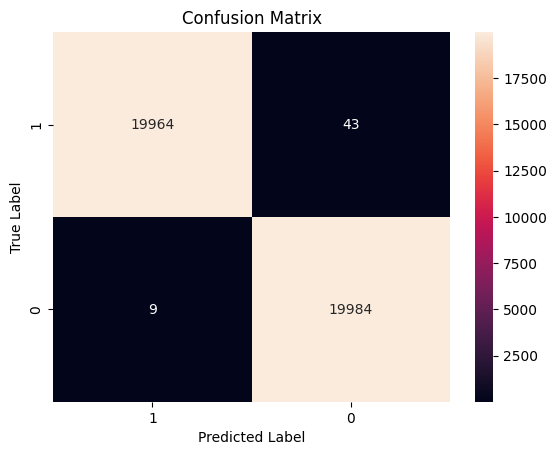

In [37]:
cm = confusion_matrix(y_true, y_preds)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [38]:
tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Negative:", fn)
print("True Positive:", tp)
print("False Positive:", fp)

True Negative: 19984
False Negative: 43
True Positive: 19964
False Positive: 9
